# Debug: Why Suite2p+Cellpose Detects Blood Vessels Differently

This notebook explains **why running Cellpose through Suite2p produces different (often larger) masks around blood vessels** compared to running Cellpose standalone on planar-stitched images.

## TL;DR: The Key Differences

| Factor | Suite2p Pipeline | Standalone Cellpose |
|--------|------------------|--------------------|
| **Input Image** | Enhanced mean image (`meanImgE`) with contrast enhancement | Raw max/mean projection |
| **Spatial High-Pass Filter** | Applied (`spatial_hp_cp=0.5`) - removes large structures | Not applied |
| **Cell Probability Threshold** | Default: `-6` (very permissive) | Default: `0.0` (conservative) |
| **Normalization** | Multiple rounds (percentile + Cellpose internal) | Single normalize99 |

**The spatial high-pass filter is the main culprit** - it's designed to enhance small cells but can inadvertently create edge artifacts around large dark structures like blood vessels.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import tifffile
from pathlib import Path

from cellpose import models, core, transforms
from cellpose.plot import mask_rgb

print(f"GPU available: {core.use_gpu()}")

GPU available: True


## Configuration

In [2]:
# === EDIT THIS: Path to your data ===
# Can be a single plane TIFF or a max projection
INPUT_PATH = Path(r"D:\raw_scanimage_tiffs\cellpose_comparison\max_proj_zstack.tif")
OUTPUT_DIR = INPUT_PATH.parent / "debug_s2p_cellpose"
OUTPUT_DIR.mkdir(exist_ok=True)

# Pick which plane to analyze (if 3D)
PLANE_IDX = 7  # Middle plane typically

# Suite2p default parameters
DIAMETER = 6
SPATIAL_HP_CP = 0.5  # Suite2p default
CELLPROB_S2P = -6    # Suite2p default (very permissive!)
CELLPROB_STANDALONE = 0.0  # Cellpose default

## Load Data

In [3]:
# Load image
data = tifffile.imread(INPUT_PATH)
print(f"Loaded shape: {data.shape}")

# Extract single plane if 3D
if data.ndim == 3:
    img_raw = data[PLANE_IDX].astype(np.float32)
    print(f"Using plane {PLANE_IDX}")
else:
    img_raw = data.astype(np.float32)

print(f"Image shape: {img_raw.shape}, dtype: {img_raw.dtype}")
print(f"Value range: [{img_raw.min():.1f}, {img_raw.max():.1f}]")

Loaded shape: (14, 448, 448)
Using plane 7
Image shape: (448, 448), dtype: float32
Value range: [396.0, 10644.0]


## Step-by-Step: Suite2p Preprocessing Pipeline

Suite2p applies these transformations in `suite2p/detection/anatomical.py:select_rois()`:

1. **Percentile normalization** (normalize99)
2. **Spatial high-pass filter** (subtract Gaussian blur)
3. **Cellpose's internal normalize99**

In [4]:
def normalize99(img):
    """Normalize to 1st and 99th percentiles (same as Cellpose)."""
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

def suite2p_preprocess(img, diameter=6, spatial_hp_cp=0.5):
    """
    Replicate Suite2p's preprocessing before Cellpose.
    From suite2p/detection/anatomical.py lines 212-214
    """
    # Step 1: Normalize to [0, 1]
    img_norm = normalize99(img)

    # Step 2: Spatial high-pass filter
    # This subtracts a Gaussian-blurred version to enhance local contrast
    # Kernel size = diameter * spatial_hp_cp
    if spatial_hp_cp > 0:
        sigma = diameter * spatial_hp_cp  # Default: 6 * 0.5 = 3 pixels
        low_freq = gaussian_filter(img_norm, sigma)
        img_hp = img_norm - low_freq
    else:
        img_hp = img_norm

    return img_norm, img_hp

In [5]:
# Apply preprocessing
img_norm, img_hp = suite2p_preprocess(img_raw, DIAMETER, SPATIAL_HP_CP)

# For comparison: what standalone Cellpose sees (just normalize99)
img_standalone = normalize99(img_raw)

print(f"Raw range: [{img_raw.min():.2f}, {img_raw.max():.2f}]")
print(f"Normalized range: [{img_norm.min():.2f}, {img_norm.max():.2f}]")
print(f"After HP filter range: [{img_hp.min():.2f}, {img_hp.max():.2f}]")

Raw range: [396.00, 10644.00]
Normalized range: [0.00, 1.00]
After HP filter range: [-0.41, 0.85]


## Visualize the Preprocessing Difference

**Key insight**: The spatial high-pass filter creates bright "halos" around dark regions (like blood vessels). Cellpose interprets these halos as cell-like structures.

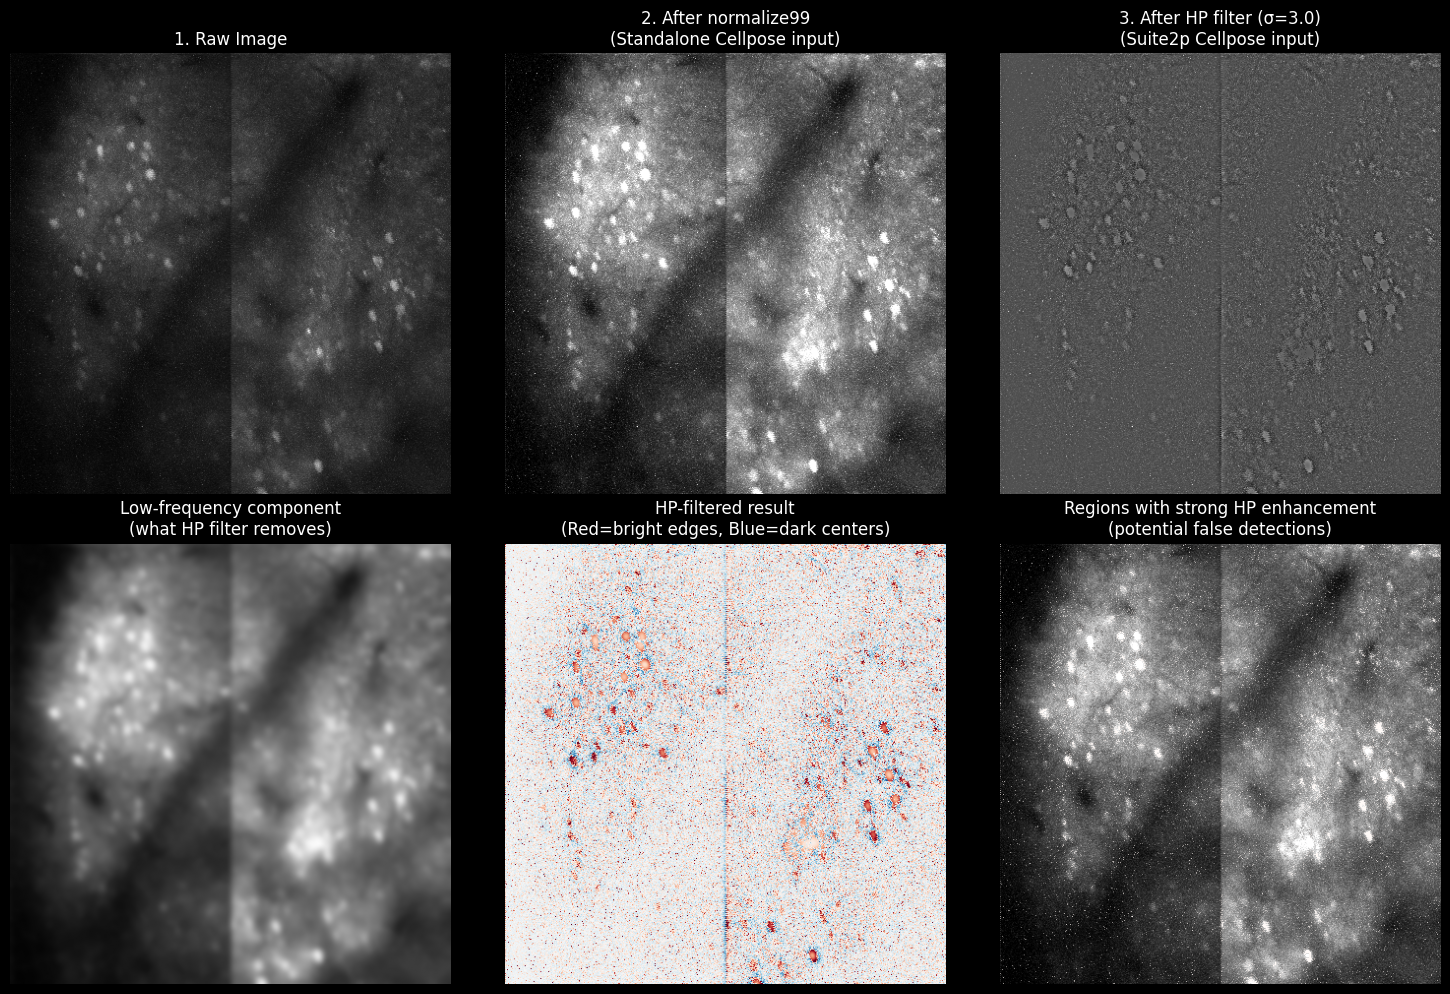

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Full images
axes[0, 0].imshow(img_raw, cmap='gray')
axes[0, 0].set_title('1. Raw Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_norm, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('2. After normalize99\n(Standalone Cellpose input)')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_hp, cmap='gray')
axes[0, 2].set_title(f'3. After HP filter (σ={DIAMETER * SPATIAL_HP_CP})\n(Suite2p Cellpose input)')
axes[0, 2].axis('off')

# Row 2: Difference visualization
# What the HP filter removes (low frequencies)
low_freq = gaussian_filter(img_norm, DIAMETER * SPATIAL_HP_CP)
axes[1, 0].imshow(low_freq, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Low-frequency component\n(what HP filter removes)')
axes[1, 0].axis('off')

# The difference (what HP filter enhances)
diff = img_hp  # This IS the difference
axes[1, 1].imshow(diff, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 1].set_title('HP-filtered result\n(Red=bright edges, Blue=dark centers)')
axes[1, 1].axis('off')

# Highlight problematic regions
# Areas where HP creates artificial bright edges
edge_enhancement = np.abs(diff) > 0.15
axes[1, 2].imshow(img_norm, cmap='gray', vmin=0, vmax=1)
axes[1, 2].imshow(np.ma.masked_where(~edge_enhancement, edge_enhancement),
                  cmap='Reds', alpha=0.5)
axes[1, 2].set_title('Regions with strong HP enhancement\n(potential false detections)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_comparison.png', dpi=150)
plt.show()

## The Blood Vessel Problem Explained

Blood vessels appear as **dark elongated regions** in calcium imaging. When the spatial HP filter is applied:

1. The filter subtracts a blurred version of the image
2. At vessel edges, there's a sharp transition from dark (vessel) to bright (tissue)
3. The blur "smears" the dark vessel into the surrounding tissue
4. Subtracting this creates a **bright halo** around the vessel
5. Cellpose sees this halo as a potential cell boundary

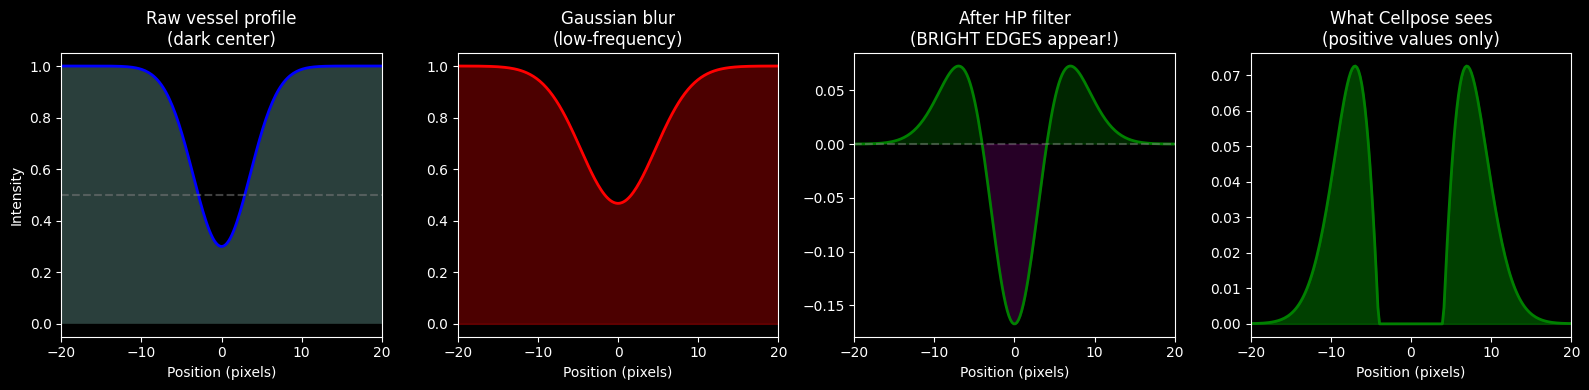

In [7]:
# Create a synthetic demonstration
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Simulate a blood vessel cross-section profile
x = np.linspace(-20, 20, 200)
vessel_profile = 1.0 - 0.7 * np.exp(-x**2 / 25)  # Dark center, bright surround

# Apply HP filter (subtract Gaussian blur)
from scipy.ndimage import gaussian_filter1d
sigma = DIAMETER * SPATIAL_HP_CP
blurred = gaussian_filter1d(vessel_profile, sigma * 5)  # Scale for 1D
hp_profile = vessel_profile - blurred

axes[0].plot(x, vessel_profile, 'b-', linewidth=2)
axes[0].fill_between(x, 0, vessel_profile, alpha=0.3)
axes[0].set_title('Raw vessel profile\n(dark center)')
axes[0].set_ylabel('Intensity')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

axes[1].plot(x, blurred, 'r-', linewidth=2)
axes[1].fill_between(x, 0, blurred, alpha=0.3, color='red')
axes[1].set_title('Gaussian blur\n(low-frequency)')

axes[2].plot(x, hp_profile, 'g-', linewidth=2)
axes[2].fill_between(x, 0, hp_profile, where=hp_profile > 0, alpha=0.3, color='green')
axes[2].fill_between(x, 0, hp_profile, where=hp_profile < 0, alpha=0.3, color='purple')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('After HP filter\n(BRIGHT EDGES appear!)')
axes[2].annotate('False cell-like\nedges!', xy=(8, 0.1), fontsize=10, color='green',
                 ha='center', fontweight='bold')

# What Cellpose "sees" for cell detection
axes[3].plot(x, np.maximum(hp_profile, 0), 'g-', linewidth=2)
axes[3].fill_between(x, 0, np.maximum(hp_profile, 0), alpha=0.5, color='green')
axes[3].set_title('What Cellpose sees\n(positive values only)')
axes[3].annotate('Detected as\n"cell boundary"', xy=(8, 0.08), fontsize=10,
                 color='darkgreen', ha='center', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Position (pixels)')
    ax.set_xlim(-20, 20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vessel_hp_filter_effect.png', dpi=150)
plt.show()

## Run Cellpose: Suite2p-style vs Standalone

In [8]:
# Initialize model
model = models.CellposeModel(gpu=core.use_gpu())

In [9]:
# Run Cellpose with Suite2p preprocessing + threshold
masks_s2p, flows_s2p, _ = model.eval(
    img_hp,  # HP-filtered image (Suite2p style)
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_S2P,  # -6 (very permissive)
    flow_threshold=0.0
)
print(f"Suite2p-style: {masks_s2p.max()} cells detected")

Resizing is deprecated in v4.0.1+


Suite2p-style: 61 cells detected


In [10]:
# Run Cellpose standalone (no HP filter, default threshold)
masks_standalone, flows_standalone, _ = model.eval(
    img_standalone,  # Just normalized (standalone style)
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_STANDALONE,  # 0.0 (default)
    flow_threshold=0.4  # Cellpose default
)
print(f"Standalone: {masks_standalone.max()} cells detected")

Resizing is deprecated in v4.0.1+


Standalone: 11 cells detected


In [11]:
# Also run standalone with Suite2p's permissive threshold for fair comparison
masks_standalone_permissive, _, _ = model.eval(
    img_standalone,
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_S2P,  # Same as S2P: -6
    flow_threshold=0.0
)
print(f"Standalone (permissive threshold): {masks_standalone_permissive.max()} cells detected")

Resizing is deprecated in v4.0.1+


Standalone (permissive threshold): 80 cells detected


## Compare Results

In [12]:
def mask_overlay(img, mask, alpha=0.5):
    """Create RGB overlay of colored masks on grayscale image."""
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([img_norm] * 3, axis=-1)
    if mask.max() > 0:
        colors = mask_rgb(mask)
        mask_px = mask > 0
        rgb[mask_px] = (1 - alpha) * rgb[mask_px] + alpha * colors[mask_px]
    return np.clip(rgb, 0, 1)

def get_mask_sizes(masks):
    """Get size of each mask."""
    if masks.max() == 0:
        return np.array([])
    return np.array([np.sum(masks == i) for i in range(1, masks.max() + 1)])

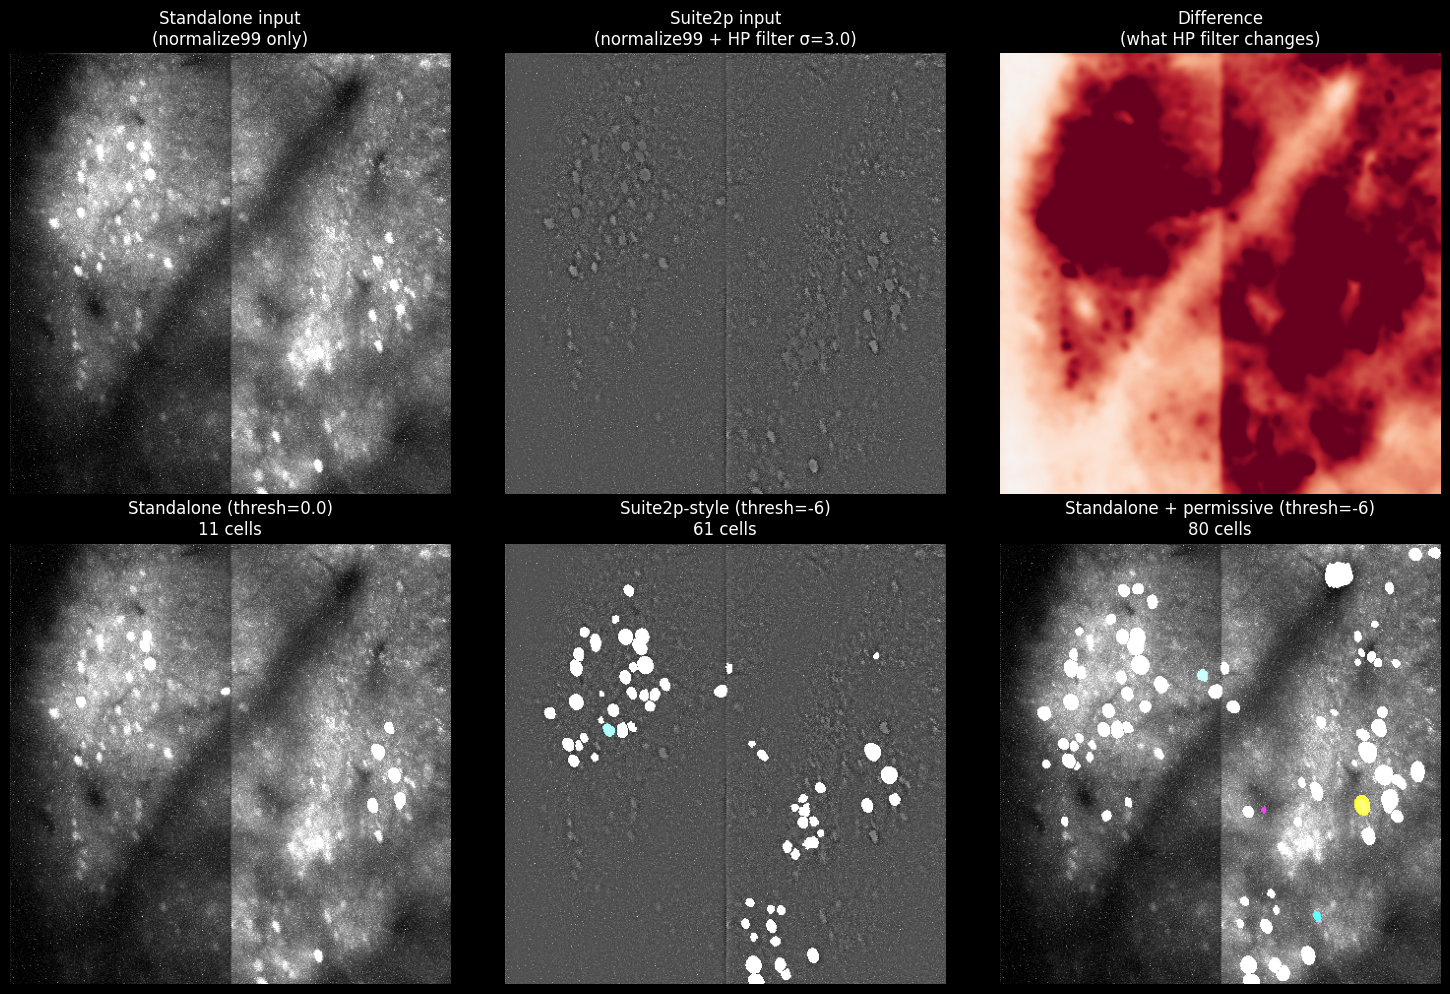

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Input images
axes[0, 0].imshow(img_standalone, cmap='gray')
axes[0, 0].set_title('Standalone input\n(normalize99 only)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_hp, cmap='gray')
axes[0, 1].set_title(f'Suite2p input\n(normalize99 + HP filter σ={DIAMETER * SPATIAL_HP_CP})')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_standalone - img_hp, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0, 2].set_title('Difference\n(what HP filter changes)')
axes[0, 2].axis('off')

# Row 2: Mask results
axes[1, 0].imshow(mask_overlay(img_standalone, masks_standalone))
axes[1, 0].set_title(f'Standalone (thresh={CELLPROB_STANDALONE})\n{masks_standalone.max()} cells')
axes[1, 0].axis('off')

axes[1, 1].imshow(mask_overlay(img_hp, masks_s2p))
axes[1, 1].set_title(f'Suite2p-style (thresh={CELLPROB_S2P})\n{masks_s2p.max()} cells')
axes[1, 1].axis('off')

axes[1, 2].imshow(mask_overlay(img_standalone, masks_standalone_permissive))
axes[1, 2].set_title(f'Standalone + permissive (thresh={CELLPROB_S2P})\n{masks_standalone_permissive.max()} cells')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'detection_comparison.png', dpi=150)
plt.show()

## Analyze Large Masks (Likely Blood Vessels)

In [14]:
# Find unusually large masks
sizes_s2p = get_mask_sizes(masks_s2p)
sizes_standalone = get_mask_sizes(masks_standalone)

# Expected cell size based on diameter
expected_area = np.pi * (DIAMETER / 2) ** 2
large_threshold = expected_area * 4  # 4x expected size

print(f"Expected cell area: ~{expected_area:.0f} pixels (diameter={DIAMETER})")
print(f"Large mask threshold: >{large_threshold:.0f} pixels")
print()
print(f"Suite2p-style:")
print(f"  Total masks: {len(sizes_s2p)}")
print(f"  Large masks (>{large_threshold:.0f}px): {np.sum(sizes_s2p > large_threshold)}")
print(f"  Median size: {np.median(sizes_s2p):.0f} px")
print(f"  Max size: {sizes_s2p.max():.0f} px")
print()
print(f"Standalone:")
print(f"  Total masks: {len(sizes_standalone)}")
print(f"  Large masks (>{large_threshold:.0f}px): {np.sum(sizes_standalone > large_threshold)}")
if len(sizes_standalone) > 0:
    print(f"  Median size: {np.median(sizes_standalone):.0f} px")
    print(f"  Max size: {sizes_standalone.max():.0f} px")

Expected cell area: ~28 pixels (diameter=6)
Large mask threshold: >113 pixels

Suite2p-style:
  Total masks: 61
  Large masks (>113px): 29
  Median size: 104 px
  Max size: 247 px

Standalone:
  Total masks: 11
  Large masks (>113px): 5
  Median size: 102 px
  Max size: 177 px


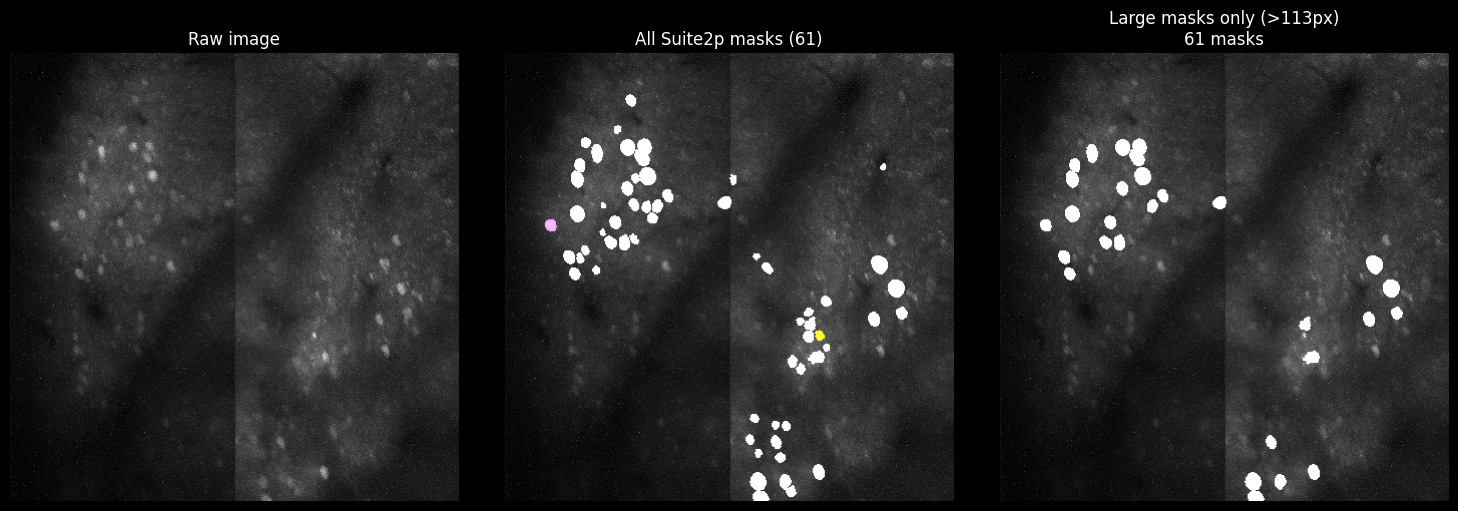

In [15]:
# Highlight large masks
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Create mask of only large detections
large_mask_s2p = np.zeros_like(masks_s2p)
for i, size in enumerate(sizes_s2p, 1):
    if size > large_threshold:
        large_mask_s2p[masks_s2p == i] = i

axes[0].imshow(img_raw, cmap='gray')
axes[0].set_title('Raw image')
axes[0].axis('off')

axes[1].imshow(mask_overlay(img_raw, masks_s2p))
axes[1].set_title(f'All Suite2p masks ({masks_s2p.max()})')
axes[1].axis('off')

axes[2].imshow(mask_overlay(img_raw, large_mask_s2p))
axes[2].set_title(f'Large masks only (>{large_threshold:.0f}px)\n{large_mask_s2p.max()} masks')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'large_masks_highlighted.png', dpi=150)
plt.show()

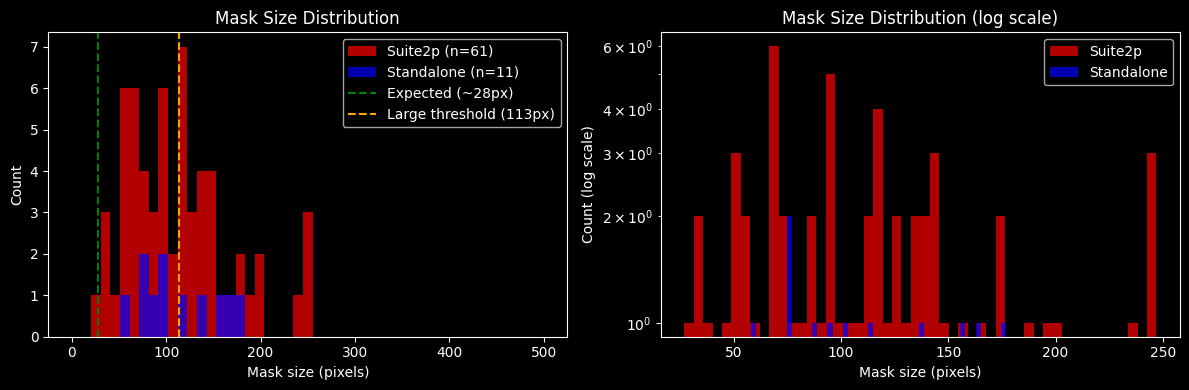

In [16]:
# Size distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, 500, 50)

axes[0].hist(sizes_s2p, bins=bins, alpha=0.7, label=f'Suite2p (n={len(sizes_s2p)})', color='red')
if len(sizes_standalone) > 0:
    axes[0].hist(sizes_standalone, bins=bins, alpha=0.7, label=f'Standalone (n={len(sizes_standalone)})', color='blue')
axes[0].axvline(expected_area, color='green', linestyle='--', label=f'Expected (~{expected_area:.0f}px)')
axes[0].axvline(large_threshold, color='orange', linestyle='--', label=f'Large threshold ({large_threshold:.0f}px)')
axes[0].set_xlabel('Mask size (pixels)')
axes[0].set_ylabel('Count')
axes[0].set_title('Mask Size Distribution')
axes[0].legend()

# Log scale to see large masks
axes[1].hist(sizes_s2p, bins=50, alpha=0.7, label='Suite2p', color='red')
if len(sizes_standalone) > 0:
    axes[1].hist(sizes_standalone, bins=50, alpha=0.7, label='Standalone', color='blue')
axes[1].set_xlabel('Mask size (pixels)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_yscale('log')
axes[1].set_title('Mask Size Distribution (log scale)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'size_distribution.png', dpi=150)
plt.show()

## Solutions to Reduce Blood Vessel Detection

### Option 1: Disable Spatial HP Filter (Recommended)
Set `spatial_hp_cp=0` in Suite2p ops

In [17]:
# Run without HP filter
masks_no_hp, _, _ = model.eval(
    img_norm,  # No HP filter, just normalized
    diameter=DIAMETER,
    cellprob_threshold=CELLPROB_S2P,
    flow_threshold=0.0
)
print(f"Without HP filter: {masks_no_hp.max()} cells")

sizes_no_hp = get_mask_sizes(masks_no_hp)
print(f"Large masks: {np.sum(sizes_no_hp > large_threshold)}")

Resizing is deprecated in v4.0.1+


Without HP filter: 80 cells
Large masks: 39


### Option 2: Use Higher Cell Probability Threshold

In [18]:
# Run with higher threshold
masks_high_thresh, _, _ = model.eval(
    img_hp,
    diameter=DIAMETER,
    cellprob_threshold=0.0,  # More conservative
    flow_threshold=0.4
)
print(f"With higher threshold: {masks_high_thresh.max()} cells")

sizes_high_thresh = get_mask_sizes(masks_high_thresh)
print(f"Large masks: {np.sum(sizes_high_thresh > large_threshold)}")

Resizing is deprecated in v4.0.1+


With higher threshold: 6 cells
Large masks: 1


### Option 3: Post-hoc Filter by Size

In [19]:
# Filter out masks larger than threshold
masks_filtered = masks_s2p.copy()
for i, size in enumerate(sizes_s2p, 1):
    if size > large_threshold:
        masks_filtered[masks_s2p == i] = 0

# Relabel
from scipy.ndimage import label
masks_filtered, n_cells = label(masks_filtered > 0)
print(f"After size filter: {n_cells} cells")

After size filter: 32 cells


### Compare Solutions

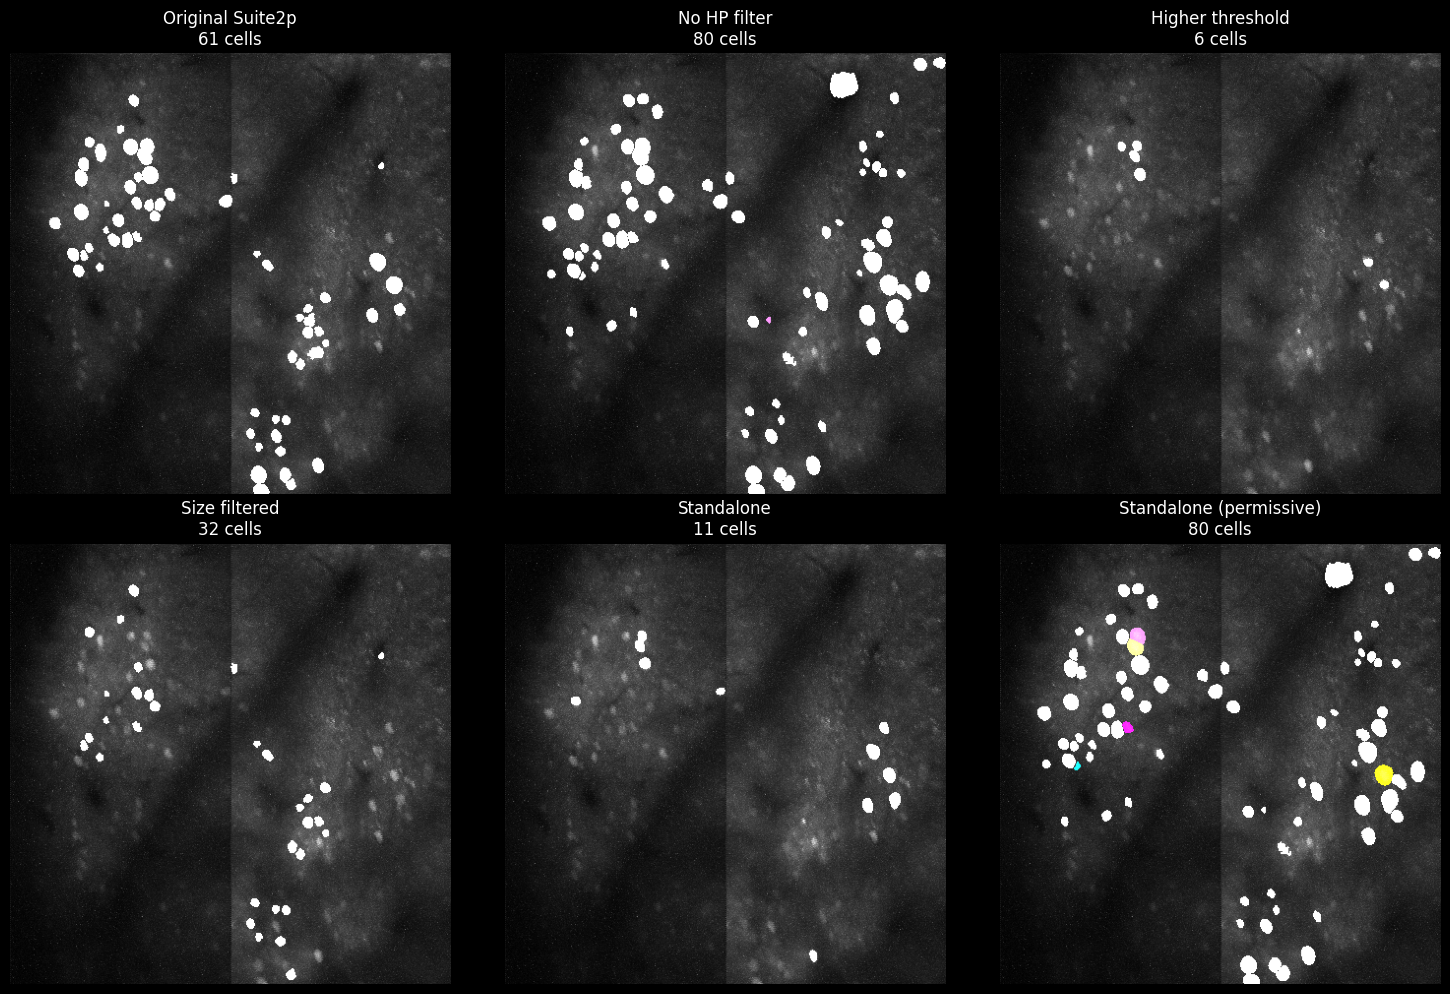

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

configs = [
    ('Original Suite2p', masks_s2p, f'{masks_s2p.max()} cells'),
    ('No HP filter', masks_no_hp, f'{masks_no_hp.max()} cells'),
    ('Higher threshold', masks_high_thresh, f'{masks_high_thresh.max()} cells'),
    ('Size filtered', masks_filtered, f'{masks_filtered.max()} cells'),
    ('Standalone', masks_standalone, f'{masks_standalone.max()} cells'),
    ('Standalone (permissive)', masks_standalone_permissive, f'{masks_standalone_permissive.max()} cells'),
]

for ax, (title, mask, subtitle) in zip(axes.flat, configs):
    ax.imshow(mask_overlay(img_raw, mask))
    ax.set_title(f'{title}\n{subtitle}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'solutions_comparison.png', dpi=150)
plt.show()

## Summary: Recommended Settings

To reduce blood vessel false positives in Suite2p+Cellpose:

```python
ops = {
    # Option 1: Disable HP filter (most effective)
    'spatial_hp_cp': 0,  # Default is 0.5
    
    # Option 2: Use more conservative threshold
    'cellprob_threshold': 0.0,  # Default is -6
    
    # Option 3: Increase flow threshold
    'flow_threshold': 0.4,  # Default is 0.0
    
    # Other relevant settings
    'diameter': 6,
    'anatomical_only': 3,
}
```

In [21]:
print("Debug notebook complete!")
print(f"\nOutput saved to: {OUTPUT_DIR}")
print("\nKey findings:")
print(f"  - Suite2p's HP filter creates edge artifacts around blood vessels")
print(f"  - Suite2p's permissive threshold (cellprob=-6) catches these artifacts")
print(f"  - Disabling HP filter (spatial_hp_cp=0) is the most effective fix")

Debug notebook complete!

Output saved to: D:\raw_scanimage_tiffs\cellpose_comparison\debug_s2p_cellpose

Key findings:
  - Suite2p's HP filter creates edge artifacts around blood vessels
  - Suite2p's permissive threshold (cellprob=-6) catches these artifacts
  - Disabling HP filter (spatial_hp_cp=0) is the most effective fix
